# TODO:
- add the possibility to continue the training of a model even after it has been already trained once

## Imports

In [1]:
from juliacall import Main as jl
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

jl.include("SolarDynamo.jl")
jl.seval("using .SolarDynamo")
sn = jl.SolarDynamo.sn
sn_from_noise = jl.SolarDynamo.sn_from_noise

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Global settings

In [2]:
TOBS = 200 # how many time steps to simulate
TWARMUP = 200 # time steps that are discarded
DT = 0.1 # Euler-Maruyama internal step
PARAM_NAMES = ["tau", "T", "Nd", "sigma", "Bmax"]

## Simulator

In [3]:
def simulate(theta, seed=None):
    tau, T, Nd, sigma, Bmax = theta
    T = round(T / DT) * DT
    
    if seed is not None:
        np.random.seed(seed)
    
    # generate noise
    Ndt = int( (TWARMUP+TOBS) / DT ) # = 4000 if TWARMUP=200,TOBS=200,DT=0.1
    eps_dt = np.random.randn(Ndt).astype(np.float64)
    
    # convert to julia types
    theta_jl = jl.Vector[jl.Float64]([tau, T, Nd, sigma, Bmax])
    eps_jl = jl.Vector[jl.Float64](eps_dt)
    
    # stochastic simulation
    x = sn_from_noise(theta_jl, eps_jl, Twarmup=TWARMUP, Tobs=TOBS, dt=DT)
    x = np.array(x, dtype=np.float32)
    
    # extract from eps_dt just the non-warmup portion
    warmup_steps = int(TWARMUP / DT)
    # compute the sum of noise per block
    k = int(1.0/DT)
    eps_obs = np.array([
        np.sum( eps_dt[warmup_steps+i*k : warmup_steps + (i+1)*k] )
        for i in range(TOBS)], dtype=np.float32)
    eps_obs /= np.sqrt(k)
    
    return x, eps_obs

## Filename helper

In [4]:
def make_basename(n_samples, fixed, prior):
    fixed_text = "-".join([str(v) for v in fixed.values()])
    prior_text = "_".join([
        f"{k}={priors[k][0]},{priors[k][1]}"
        for k in PARAM_NAMES
        if fixed.get(k) is None and isinstance(priors.get(k), tuple)
    ])
    return f"{n_samples}__{fixed_text}__{prior_text}"

## Dataset generator

In [5]:
def generate_dataset(n_samples, fixed, priors):
    varying_names = [k for k,v in fixed.items() if v is None]
    n_params = len(varying_names)
    
    # create the dataset
    X = np.zeros((n_samples, TOBS), dtype=np.float32)
    Noise = np.zeros((n_samples, TOBS), dtype=np.float32)
    Params = np.zeros((n_samples, n_params), dtype=np.float32)

    for i in range(n_samples):
        theta = {}
        for name in PARAM_NAMES:
            if fixed[name] is not None:
                theta[name] = fixed[name]
            else:
                low, high = priors[name]
                theta[name] = np.random.uniform(low,high)
                
        x, noise = simulate([theta[k] for k in PARAM_NAMES])
        X[i] = x
        Noise[i] = noise
        Params[i] = [theta[k] for k in varying_names]

        if (i+1)%50 == 0:
            print(f"Generated {i+1}/{n_samples} samples", end="\r")
    
    print()
    
    # normalize x
    x_mean = X.mean()
    x_std = X.std()

    # don't normalize noise because already normalized
    n_mean = 0
    n_std = 1

    # normalize parameters
    p_mean = Params.mean(axis=0)
    p_std  = Params.std(axis=0)
    p_std[p_std == 0] = 1.0
        
    stats = {
        "x_mean": x_mean, "x_std": x_std,
        "n_mean": n_mean, "n_std": n_std,
        "p_mean": p_mean, "p_std": p_std
    }
    
    X = (X - x_mean) / x_std
    Params = (Params - p_mean) / p_std
    
    return X, Noise, Params, stats

## Saving / Loading datasets

In [6]:
def save_dataset(X, Noise, Params, stats, n_samples, fixed, priors, folder="data"):
    os.makedirs(folder, exist_ok=True)
    
    base = make_basename(n_samples, fixed, priors)
        
    np.save(os.path.join(folder, f"X_{base}.npy"), X)
    np.save(os.path.join(folder, f"Noise_{base}.npy"), Noise)
    np.save(os.path.join(folder, f"Params_{base}.npy"), Params)
    np.save(os.path.join(folder, f"stats_{base}.npy"), stats, allow_pickle=True)
    print(f"Saved → {folder}/{base}\n")

def load_dataset(n_samples, fixed, priors, folder="data"):
    base = make_basename(n_samples, fixed, priors)
    
    try:
        X = np.load(os.path.join(folder, f"X_{base}.npy"))
        Noise = np.load(os.path.join(folder, f"Noise_{base}.npy"))
        Params = np.load(os.path.join(folder, f"Params_{base}.npy"))
        stats = np.load(os.path.join(folder, f"stats_{base}.npy"), 
                        allow_pickle=True).item()
        print(f"Loaded ← {folder}/{base}")
        return X, Noise, Params, stats
    
    except FileNotFoundError:
        print(f"Not found: {base}. Generate it first.")
        return None

def generate_train_test_datasets(fixed, priors,
                                 n_train=5000, n_test=1000,
                                 folder="data"):
    # check if exists
    base = make_basename(n_train, fixed, priors)
    if os.path.isfile(os.path.join(folder, f"X_{base}.npy")):
        print("Dataset already exists, skipping generation.")
        return
    
    # generate and save a training dataset
    print("Generating training data...")
    X_tr, N_tr, P_tr, stats = generate_dataset(n_train, fixed, priors)
    save_dataset(X_tr, N_tr, P_tr, stats, n_train, fixed, priors, folder)

    # generate and save a test dataset
    print("Generating test data...")
    X_te, N_te, P_te, _ = generate_dataset(n_test, fixed, priors)
    save_dataset(X_te, N_te, P_te, stats, n_test, fixed, priors, folder)
    
    print("Done.")
    
def load_train_test_datasets(fixed, priors,
                             n_train=5000, n_test=1000,
                             folder="data"):
    # load datasets
    result_tr = load_dataset(n_train, fixed, priors, folder)
    result_te = load_dataset(n_test,  fixed, priors, folder)
    if result_tr is None or result_te is None:
        return None
    
    X_tr, N_tr, P_tr, stats = result_tr
    X_te, N_te, P_te, _     = result_te
    return {
        "X_train": X_tr, "N_train": N_tr, "P_train": P_tr, "stats": stats,
        "X_test":  X_te, "N_test":  N_te, "P_test":  P_te
    }

## ENCA Architecture

In [13]:
class Encoder(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        
        self.net = nn.Sequential(
            # block 1
            nn.Conv1d(1,  16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2), # halve the time dimension
            
            # block 2
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            
            # project to n_summary channels
            nn.Conv1d(32, n_summary, kernel_size=3, padding=1),
        )
        
        # average over time: (batch,n_summary,TOBS)->(batch,n_summary,1)
        self.pool = nn.AdaptiveAvgPool1d(1)
    
    def forward(self, x):
        # x: (batch,TOBS) -> add channel dim -> (batch,1,TOBS)
        x = x.unsqueeze(1)
        # x -> (batch,n_summary,TOBS/2)
        x = self.net(x)
        # x -> (batch,n_summary,1)
        x = self.pool(x)
        # x -> (batch,n_summary)
        x = x.squeeze(-1)
        
        return x


class Decoder(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        
        self.lstm = nn.LSTM(input_size=n_summary + 1, hidden_size=16, 
                            num_layers=2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, s, noise):
        s_tiled = s.unsqueeze(1).expand(-1, noise.shape[1], -1)
        noise3d = noise.unsqueeze(2) 
        inp = torch.cat([s_tiled, noise3d], dim=-1)
        
        out, _ = self.lstm(inp)
        x_hat = self.fc(out).squeeze(-1)
        
        return x_hat


class ENCA(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        
        self.encoder = Encoder(n_summary)
        self.decoder = Decoder(n_summary)
    
    def forward(self, x, noise):
        s = self.encoder(x)
        x_hat = self.decoder(s, noise)
        return s, x_hat

## Training and Evaluation

In [8]:
def train(X, Noise, Params, n_summary=None, epochs=200,
          batch_size=64, lr=1e-3):
    
    n_params = Params.shape[1]
    n_summary = n_summary or n_params+2
    
    # create the iterable dataset
    dataset = TensorDataset(
        torch.tensor(X),
        torch.tensor(Noise),
        torch.tensor(Params)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # define model, optimizer and loss function
    model = ENCA(n_summary)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # change LR at each epoch with a scheduler
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)
    loss_func = nn.MSELoss()
    
    loss_history = []
    model.train()
    
    for epoch in range(epochs):
        total_loss = [0, 0, 0]
        n_batches = 0
        
        for x_batch, n_batch, p_batch in loader:            
            # get output from the model
            s, x_hat = model(x_batch, n_batch)
            
            # calculate reconstruction loss and regression loss 
            loss_recon = loss_func(x_hat, x_batch)
            loss_regr = loss_func(s[:, :n_params], p_batch)
            loss_tot = loss_recon + loss_regr
            
            # backpropagate loss
            optimizer.zero_grad()
            loss_tot.backward()
            optimizer.step()
            
            total_loss[0] += loss_tot.item()
            total_loss[1] += loss_recon.item()
            total_loss[2] += loss_regr.item()
            n_batches += 1
        
        # save dataset loss
        avg_loss = [l/n_batches for l in total_loss]
        loss_history.append(avg_loss)
        
        # update learning rate
        scheduler.step()
        
        if (epoch+1)%20 == 0:
            lr_now = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch+1:3d}, Loss: {avg_loss[0]:.4f}, LR: {lr_now:.2e}")
            
    # plot loss curves
    loss_history = torch.tensor(loss_history)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(loss_history[:,0], label="Total loss")
    ax.plot(loss_history[:,1], linestyle="--", label="Reconstruction loss")
    ax.plot(loss_history[:,2], linestyle=":", label="Regression loss")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(f"{loss} Loss")
    ax.set_title("Training Loss Curves")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    return model

In [9]:
def evaluate(model, X, Noise, Params, stats, fixed):
    model.eval()
    with torch.no_grad():
        # prediction
        s, x_hat = model(torch.tensor(X), torch.tensor(Noise))
    
    # convert to numpy
    s = s.numpy()
    x_hat = x_hat.numpy()
    
    # un-noralize paramters to real values
    varying_names = [k for k,v in fixed.items() if v is None]
    Params_real = Params*stats["p_std"] + stats["p_mean"]
    n_params = len(varying_names)
    
    # 1) plot reconstruction (3 random examples)
    idx = np.random.choice(len(X), size=3, replace=False)
    fig, axes = plt.subplots(3,1,figsize=(10, 8),sharex=True)
    for ax,i in zip(axes,idx):
        title = ", ".join([f"{p}={Params_real[i,j]:.2f}" 
                           for j,p in enumerate(varying_names)])
        
        ax.plot(X[i], label="Original x")
        ax.plot(x_hat[i], label="Reconstructed", ls="--")
        ax.set_title(title)
    
    axes[0].legend()
    axes[-1].set_xlabel("time step")
    plt.suptitle("Reconstruction of data")
    plt.tight_layout()
    plt.show()
    
    # 2) plot s_j vs true param    
    fig, axes = plt.subplots(1, n_params, figsize=(4*n_params,4))
    if n_params == 1:
        axes = [axes]
    for i,(ax,name) in enumerate(zip(axes,varying_names)):
        ax.scatter(s[:,i], Params_real[:,i], alpha=0.3, s=8)
        ax.set_ylabel(f"true {name}")
        ax.set_xlabel(f"$s_{i}$")
        ax.set_title(f"$s_{i}$ vs {name}")
    plt.suptitle("Regression check")
    plt.tight_layout()
    plt.show()
    
    # 3) plot latent space    
    fig, ax = plt.subplots(figsize=(6,5))
    sc = ax.scatter(s[:,0], s[:,1], c=Params_real[:,0], 
                    cmap="viridis", alpha=0.4, s=12)
    plt.colorbar(sc, ax=ax, label=varying_names[0])
    ax.set_ylabel("$s_1$")
    ax.set_xlabel("$s_0$")
    plt.suptitle(f"Latent space colored by {varying_names[0]}")
    plt.tight_layout()
    plt.show()
    
    return s, x_hat

In [10]:
def run(fixed, priors, data, n_summary=None, epochs=200, 
        batch_size=64, lr=1e-3):
    
    print("\nTraining...\n")
    model = train(data["X_train"], data["N_train"], data["P_train"], 
                  n_summary=n_summary, epochs=epochs,
                  batch_size=batch_size, lr=lr)
    
    # evaluating
    print("\n" + 100*"-" + "\nEvaluating on test set...")
    s, x_hat = evaluate(model, data["X_test"], data["N_test"],
                        data["P_test"], data["stats"], fixed)
    
    return model, s, x_hat

---
# Exploring $\tau$ and T parameter space

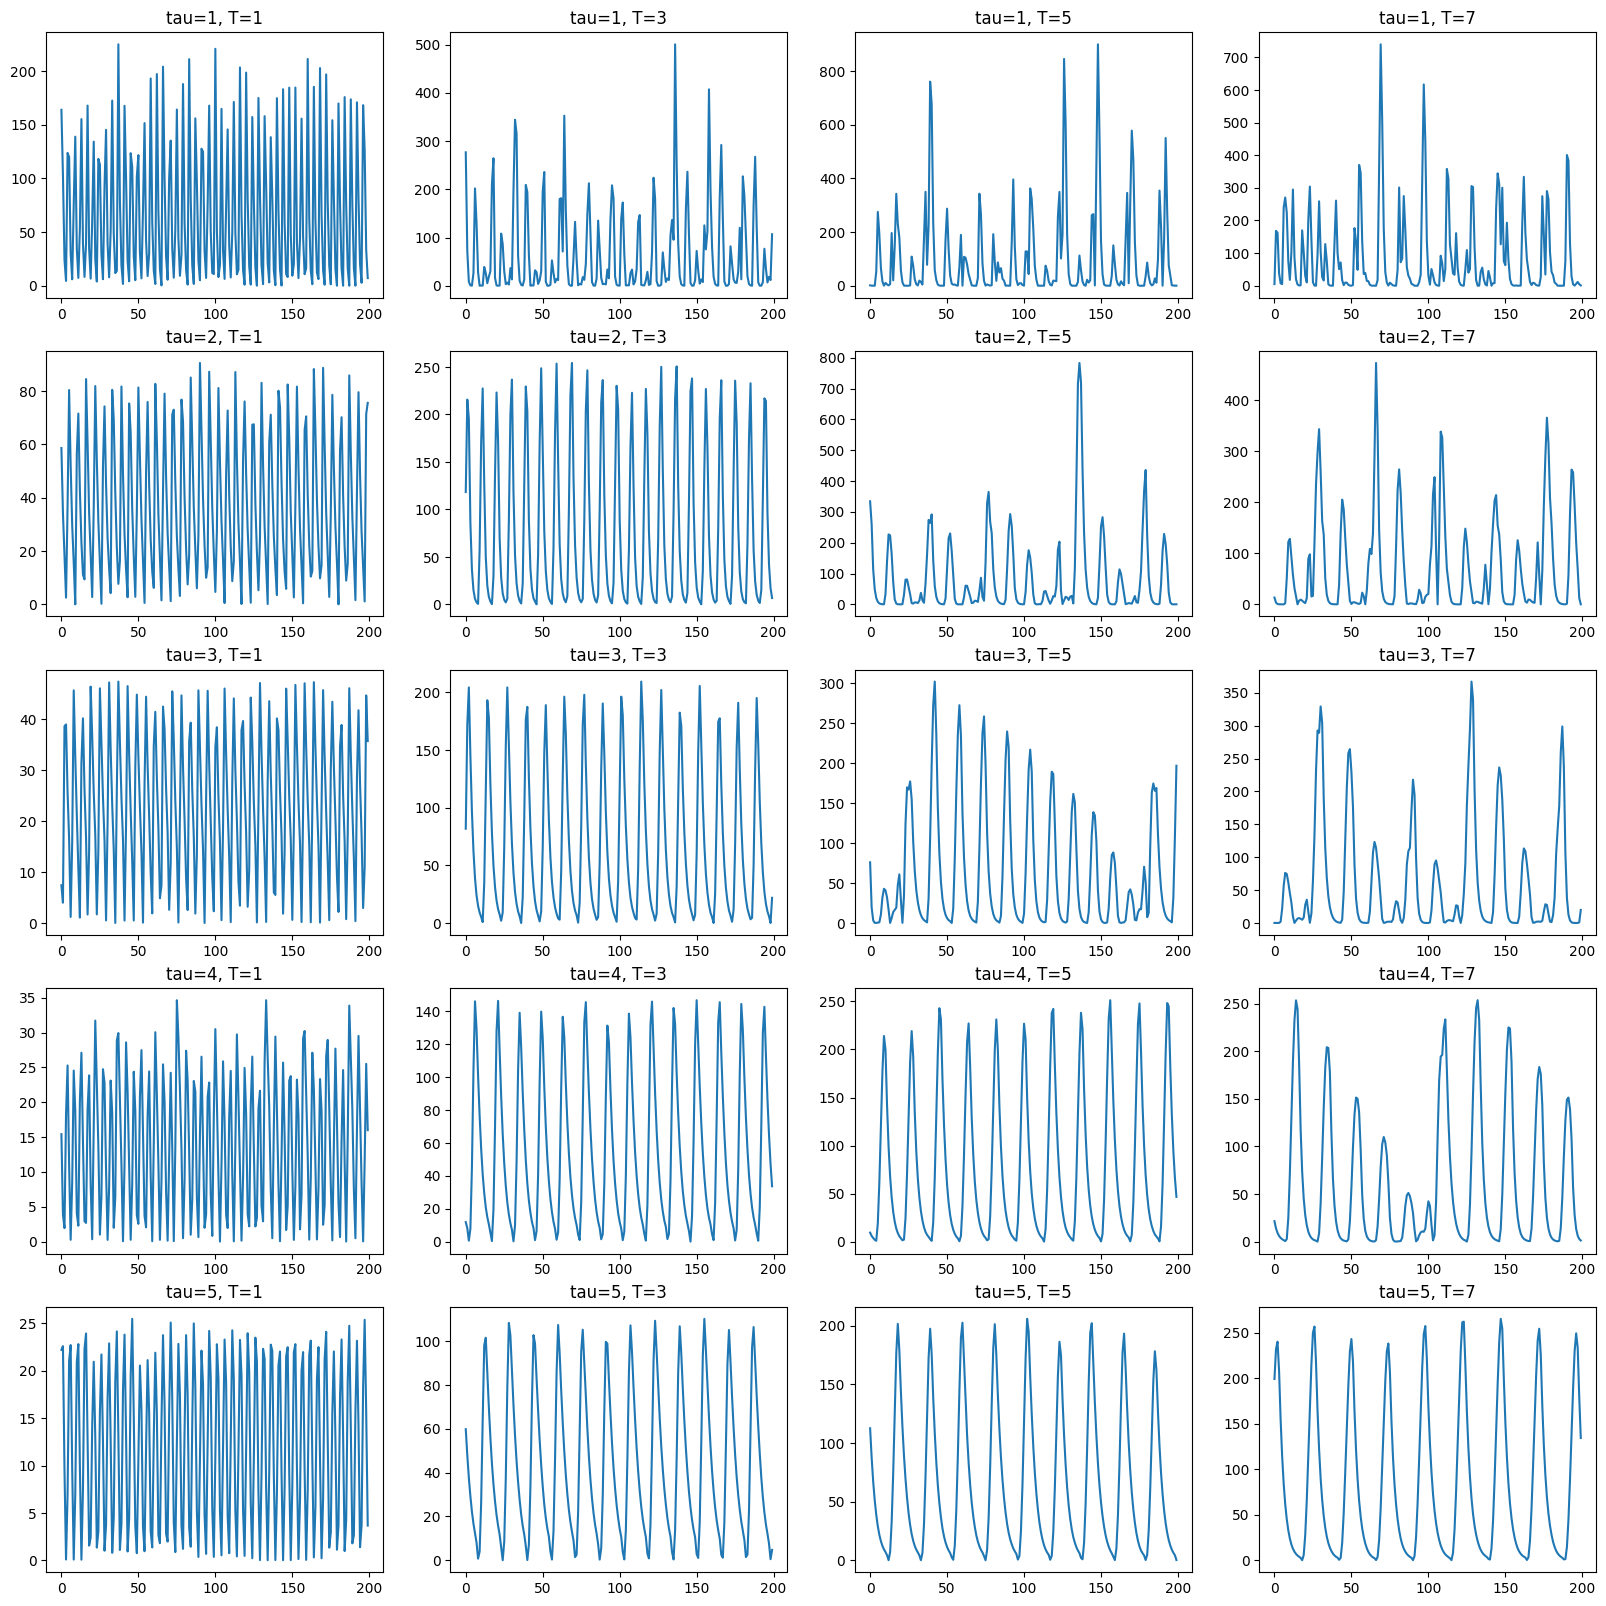

In [11]:
list_tau, list_T = [1, 2, 3, 4, 5], [1, 3, 5, 7]
fig,axes = plt.subplots(len(list_tau),len(list_T), figsize=(20,20))
for i,tau in enumerate(list_tau):
    for j,T in enumerate(list_T):
        params = [tau, T, 11, 0.05, 5]
        x, _ = simulate(params)
        axes[i,j].plot(x, label=f"tau={tau}, T={T}")
        axes[i,j].set_title(f"tau={tau}, T={T}")

plt.show()

---
# 1) Fixing 4 parameters 
## Vary $N_d$

Generating training data...
Generated 10000/10000 samples
Saved → data/10000__2.8-3.7-None-0.05-5__Nd=10,12

Generating test data...
Generated 1000/1000 samples
Saved → data/1000__2.8-3.7-None-0.05-5__Nd=10,12

Done.
Loaded ← data/10000__2.8-3.7-None-0.05-5__Nd=10,12
Loaded ← data/1000__2.8-3.7-None-0.05-5__Nd=10,12

Training...

Epoch  20, Loss: 0.5176, LR: 8.18e-04
Epoch  40, Loss: 0.2684, LR: 6.69e-04
Epoch  60, Loss: 0.3647, LR: 5.47e-04
Epoch  80, Loss: 0.1850, LR: 4.48e-04
Epoch 100, Loss: 0.1484, LR: 3.66e-04
Epoch 120, Loss: 0.1338, LR: 2.99e-04
Epoch 140, Loss: 0.1237, LR: 2.45e-04
Epoch 160, Loss: 0.1092, LR: 2.00e-04
Epoch 180, Loss: 0.1213, LR: 1.64e-04
Epoch 200, Loss: 0.1426, LR: 1.34e-04


NameError: name 'loss' is not defined

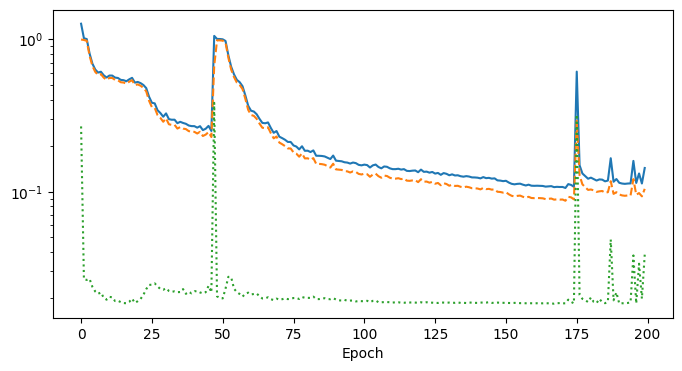

In [16]:
priors = {
    "tau": (1,5), 
    "T": (1,3), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": 2.8,
    "T": 3.7, 
    "Nd": None, 
    "sigma": 0.05, 
    "Bmax": 5
}

n_train, n_test = 10000, 1000
epochs = 200

generate_train_test_datasets(fixed, priors, n_train=n_train, n_test=n_test)
data = load_train_test_datasets(fixed, priors, n_train=n_train, n_test=n_test)
model, s, x_hat = run(fixed, priors, data, epochs=epochs)

---
# 2) Fixing 2 parameters 
## Vary $N_d$ and $\sigma$

In [ ]:
priors = {
    "tau": (1,5), 
    "T": (1,3), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": 2.8,
    "T": 3.7, 
    "Nd": None, 
    "sigma": None, 
    "Bmax": 5
}

n_train, n_test = 10000, 1000
epochs = 200

generate_train_test_datasets(fixed, priors, n_train=n_train, n_test=n_test)
data = load_train_test_datasets(fixed, priors, n_train=n_train, n_test=n_test)
model, s, x_hat = run(fixed, priors, data, epochs=epochs)

## Vary $\tau$ and T

In [ ]:
priors = {
    "tau": (1,5), 
    "T": (1,3), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": None,
    "T": None,
    "Nd": 11,
    "sigma": 0.15,
    "Bmax": 5
}

n_train, n_test = 10000, 1000
epochs = 200

generate_train_test_datasets(fixed, priors, n_train=n_train, n_test=n_test)
data = load_train_test_datasets(fixed, priors, n_train=n_train, n_test=n_test)
model, s, x_hat = run(fixed, priors, data, epochs=epochs)

---
# Dataset creation

In [65]:
fixed = {
    "tau": None,
    "T": None,
    "Nd": None,
    "sigma": None,
    "Bmax": 5
}
generate_train_test_datasets(fixed, 20000, 1000)

Generating training data...
Generated 20000/20000 samples
Dataset saved to data/

Generating test data...
Generated 1000/1000 samples
Dataset saved to data/

Done.


---
# 1) Fixing 4 parameters 
## Vary $N_d$
Training with paper priors


----------------------------------------------------------------------------------------------------
Training...
Epoch  20, Loss: 0.9337, LR: 5.44e-04
Epoch  40, Loss: 0.5215, LR: 2.96e-04
Epoch  60, Loss: 0.4445, LR: 1.61e-04
Epoch  80, Loss: 0.4189, LR: 8.74e-05
Epoch 100, Loss: 0.4085, LR: 4.76e-05
Epoch 120, Loss: 0.4013, LR: 2.59e-05
Epoch 140, Loss: 0.3994, LR: 1.41e-05
Epoch 160, Loss: 0.3973, LR: 7.65e-06
Epoch 180, Loss: 0.3969, LR: 4.16e-06
Epoch 200, Loss: 0.3959, LR: 2.26e-06


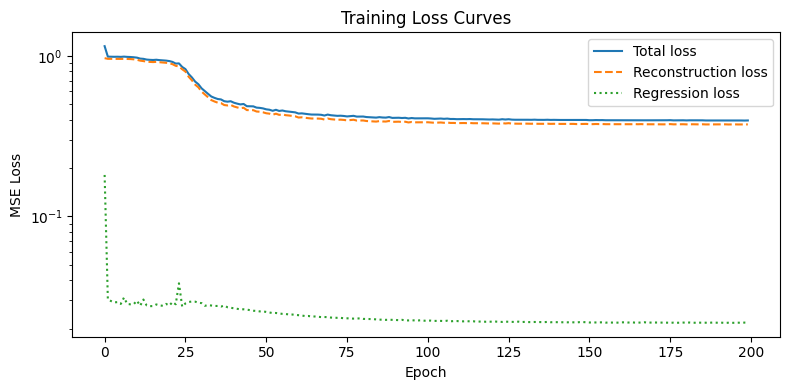


----------------------------------------------------------------------------------------------------
Evaluating on test set...


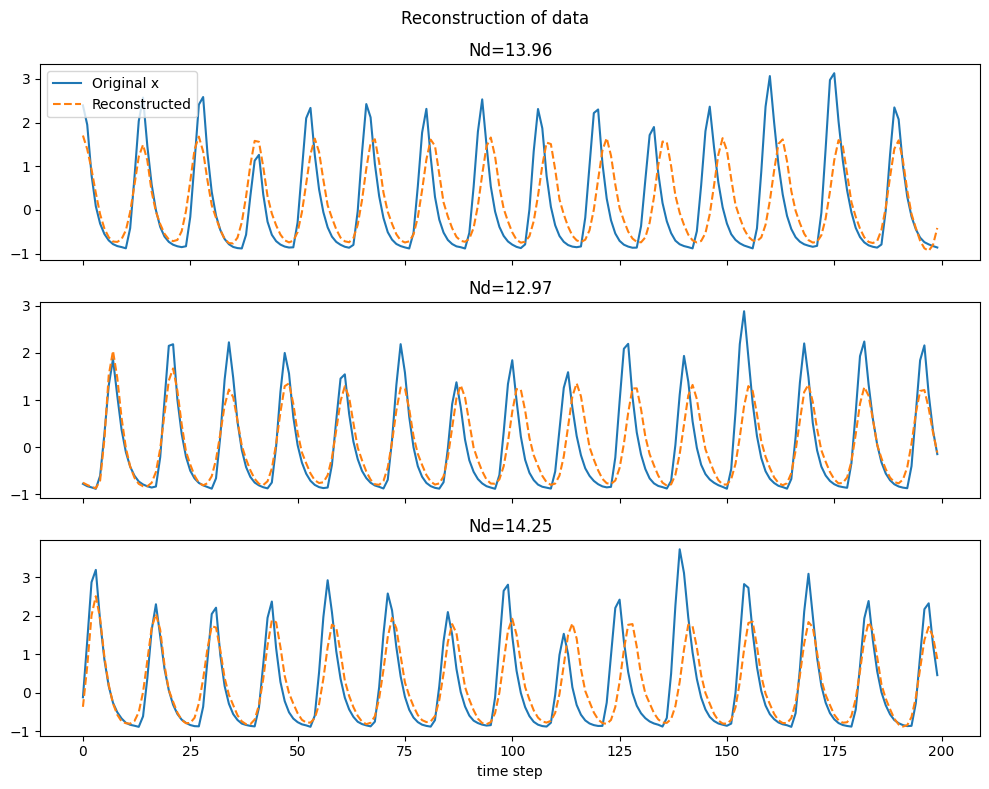

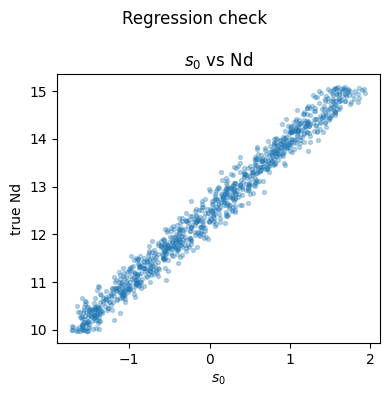

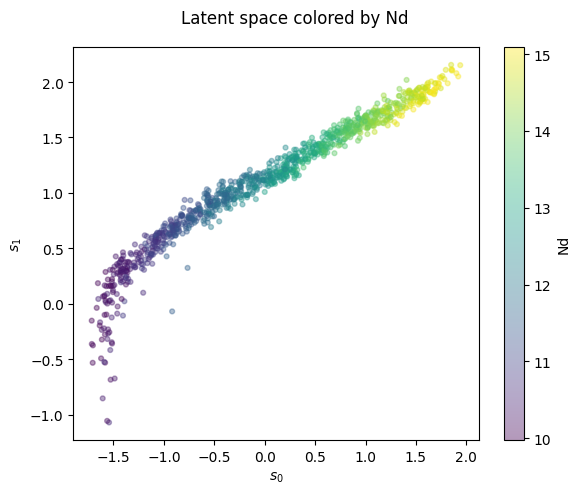

In [18]:
# load dataset
fixed = {
    "tau": 2.8,
    "T": 3.7,
    "Nd": None,
    "sigma": 0.15,
    "Bmax": 5
}
data = load_train_test_datasets(fixed, 10000, 1000)

# run experiment
res1_mse = run(fixed,
    data["X_train"], data["N_train"], data["P_train"], data["stats"],
    data["X_test"], data["N_test"], data["P_test"],
    n_summary=None, epochs=200, loss="MSE")

Training with priors = {"tau": (1, 5), "T": (1, 3), "Nd": (10, 12), "sigma": (0, 0.3)}

Dataset loaded.
Dataset loaded.

Training...

Epoch  20, Loss: 0.9902, LR: 8.18e-04
Epoch  40, Loss: 0.6855, LR: 6.69e-04
Epoch  60, Loss: 0.6579, LR: 5.47e-04
Epoch  80, Loss: 0.6416, LR: 4.48e-04
Epoch 100, Loss: 0.4044, LR: 3.66e-04
Epoch 120, Loss: 0.3516, LR: 2.99e-04
Epoch 140, Loss: 0.3169, LR: 2.45e-04
Epoch 160, Loss: 0.3053, LR: 2.00e-04
Epoch 180, Loss: 0.2901, LR: 1.64e-04
Epoch 200, Loss: 0.2813, LR: 1.34e-04


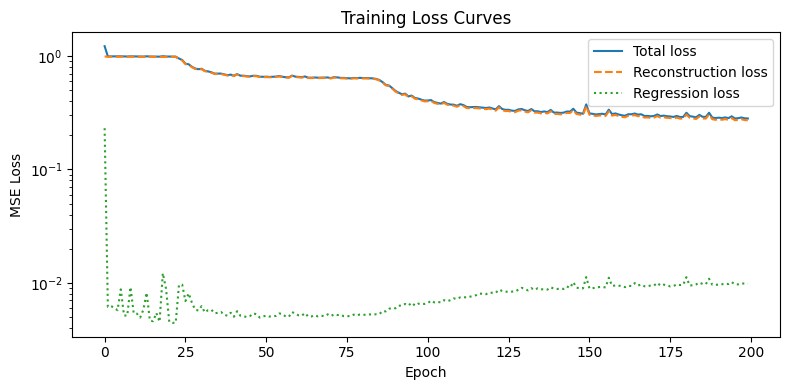


----------------------------------------------------------------------------------------------------
Evaluating on test set...


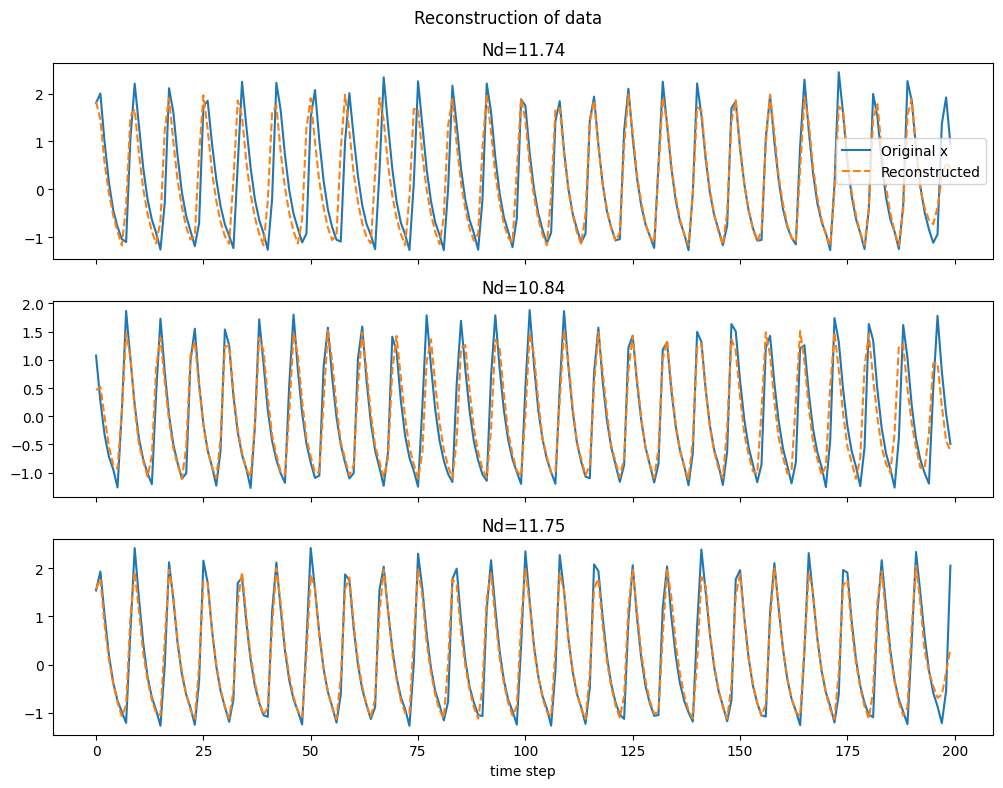

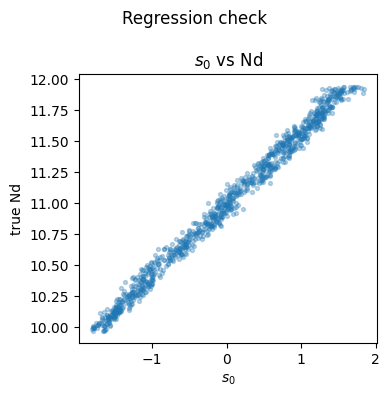

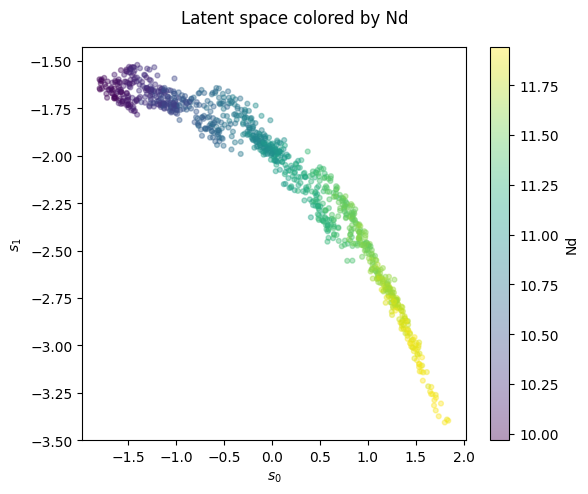

In [63]:
# load dataset
fixed = {
    "tau": 2.5,
    "T": 1.5,
    "Nd": None,
    "sigma": 0.05,
    "Bmax": 5
}
data = load_train_test_datasets(fixed, 10000, 1000)

# run experiment
res1_mse = run(fixed,
    data["X_train"], data["N_train"], data["P_train"], data["stats"],
    data["X_test"], data["N_test"], data["P_test"],
    n_summary=None, epochs=200, loss="MSE")

---
# 2) Fixing 2 parameters 
## Vary $N_d$ and $\sigma$
Training with paper priors

Dataset loaded from data/

Dataset loaded from data/


Training...

Epoch  20, Loss: 0.9730, LR: 8.18e-04
Epoch  40, Loss: 0.4763, LR: 6.69e-04
Epoch  60, Loss: 0.3983, LR: 5.47e-04
Epoch  80, Loss: 0.3706, LR: 4.48e-04
Epoch 100, Loss: 0.3588, LR: 3.66e-04
Epoch 120, Loss: 0.3494, LR: 2.99e-04
Epoch 140, Loss: 0.3473, LR: 2.45e-04
Epoch 160, Loss: 0.3404, LR: 2.00e-04
Epoch 180, Loss: 0.3342, LR: 1.64e-04
Epoch 200, Loss: 0.3326, LR: 1.34e-04


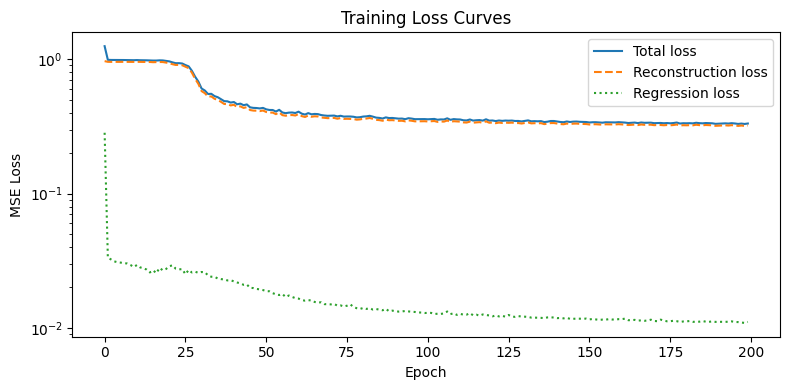


----------------------------------------------------------------------------------------------------
Evaluating on test set...


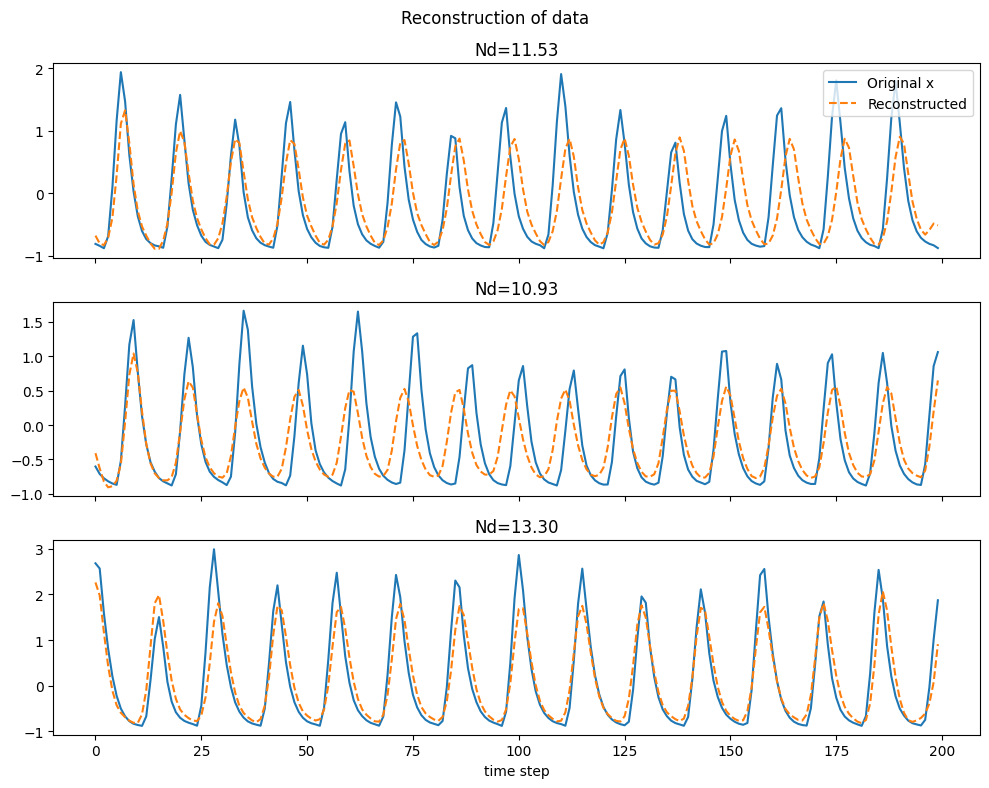

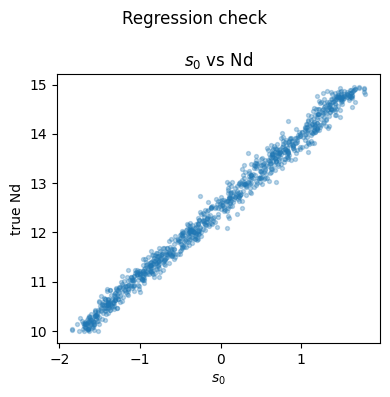

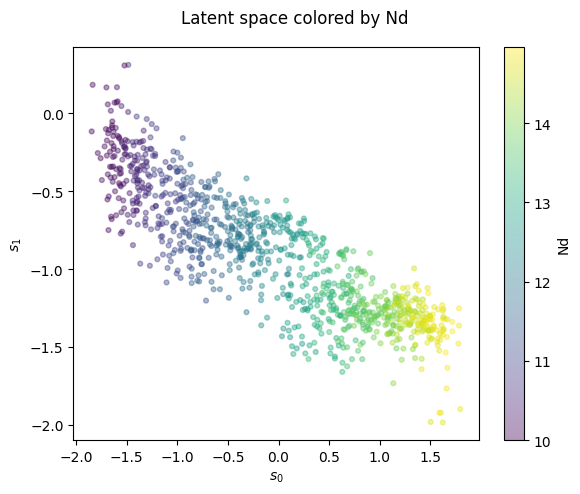

In [33]:
# load dataset
fixed = {
    "tau": 2.8,
    "T": 3.7,
    "Nd": None,
    "sigma": 0.15,
    "Bmax": 5
}
data = load_train_test_datasets(fixed, 10000, 1000)

# run experiment
res2_mse = run(fixed,
    data["X_train"], data["N_train"], data["P_train"], data["stats"],
    data["X_test"], data["N_test"], data["P_test"],
    n_summary=None, epochs=200, loss="MSE")

## Vary $\tau$ and T
Training with priors = {"tau": (1, 5), "T": (1, 8),"Nd": (10, 12),"sigma": (0, 0.3),"Bmax": (5, 5)}

Dataset loaded.
Dataset loaded.

Training...

Epoch  20, Loss: 0.9693, LR: 8.18e-04
Epoch  40, Loss: 0.9659, LR: 6.69e-04
Epoch  60, Loss: 0.9618, LR: 5.47e-04
Epoch  80, Loss: 0.9615, LR: 4.48e-04
Epoch 100, Loss: 0.9596, LR: 3.66e-04
Epoch 120, Loss: 0.9577, LR: 2.99e-04
Epoch 140, Loss: 0.9542, LR: 2.45e-04
Epoch 160, Loss: 0.9518, LR: 2.00e-04
Epoch 180, Loss: 0.9425, LR: 1.64e-04
Epoch 200, Loss: 0.9334, LR: 1.34e-04


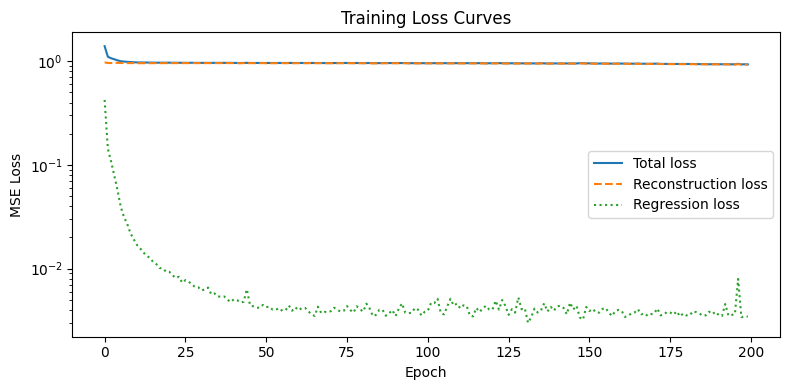


----------------------------------------------------------------------------------------------------
Evaluating on test set...


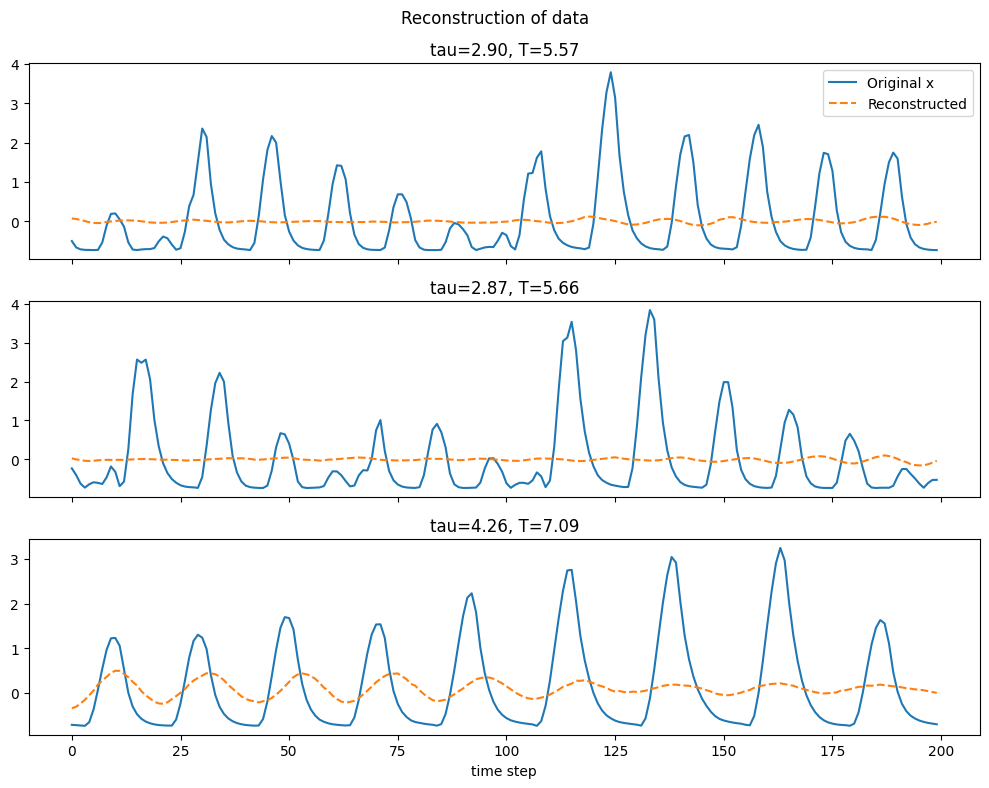

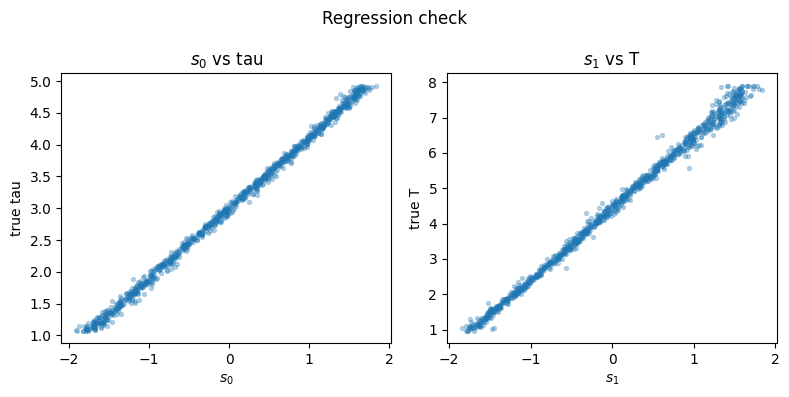

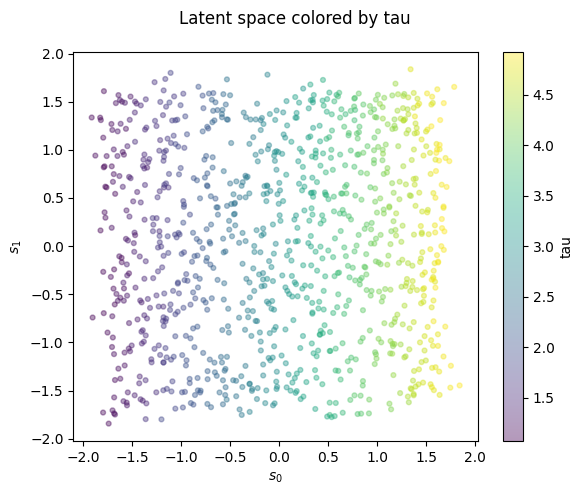

In [42]:
# load dataset
fixed = {
    "tau": None,
    "T": None,
    "Nd": 11,
    "sigma": 0.15,
    "Bmax": 5
}
data = load_train_test_datasets(fixed, 10000, 1000)

# run experiment
res2_mse = run(fixed,
    data["X_train"], data["N_train"], data["P_train"], data["stats"],
    data["X_test"], data["N_test"], data["P_test"],
    n_summary=None, epochs=200, loss="MSE")

Training with priors = {"tau": (1, 5), "T": (1, 3), "Nd": (10, 12), "sigma": (0, 0.3)}

Dataset loaded.
Dataset loaded.

Training...

Epoch  20, Loss: 0.8926, LR: 8.18e-04
Epoch  40, Loss: 0.8913, LR: 6.69e-04
Epoch  60, Loss: 0.8890, LR: 5.47e-04
Epoch  80, Loss: 0.8577, LR: 4.48e-04
Epoch 100, Loss: 0.5478, LR: 3.66e-04
Epoch 120, Loss: 0.4864, LR: 2.99e-04
Epoch 140, Loss: 0.4657, LR: 2.45e-04
Epoch 160, Loss: 0.4464, LR: 2.00e-04
Epoch 180, Loss: 0.4356, LR: 1.64e-04
Epoch 200, Loss: 0.4228, LR: 1.34e-04


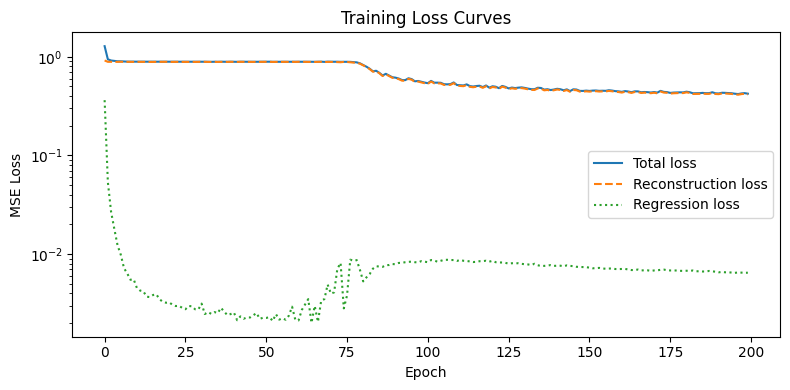


----------------------------------------------------------------------------------------------------
Evaluating on test set...


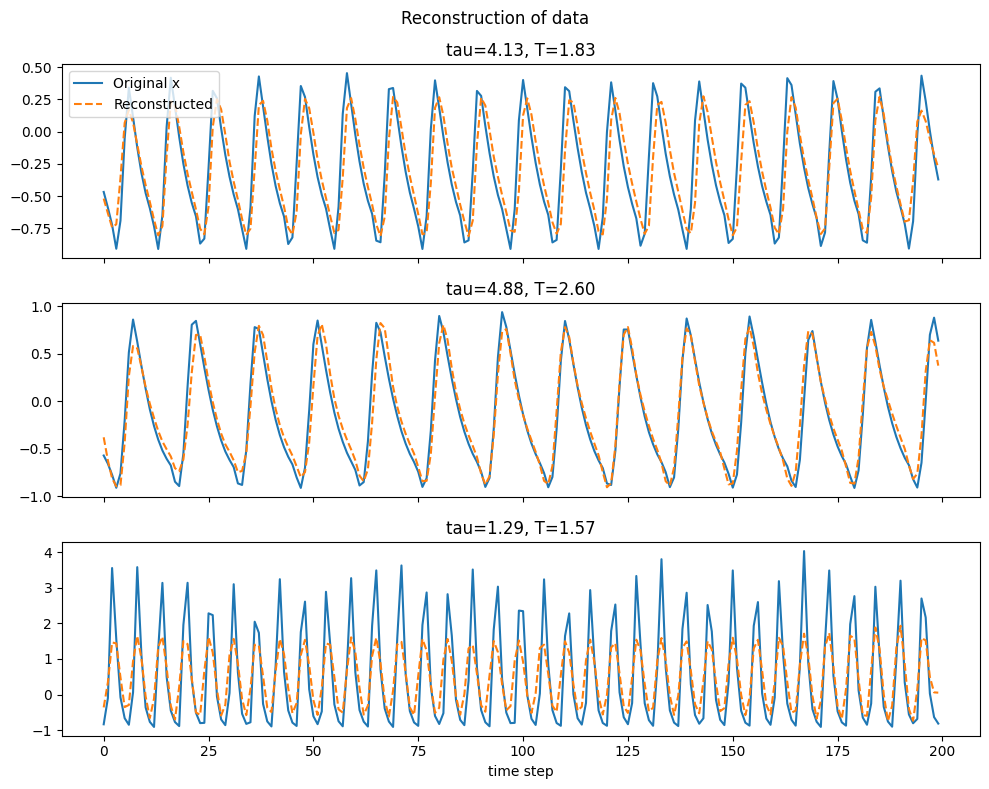

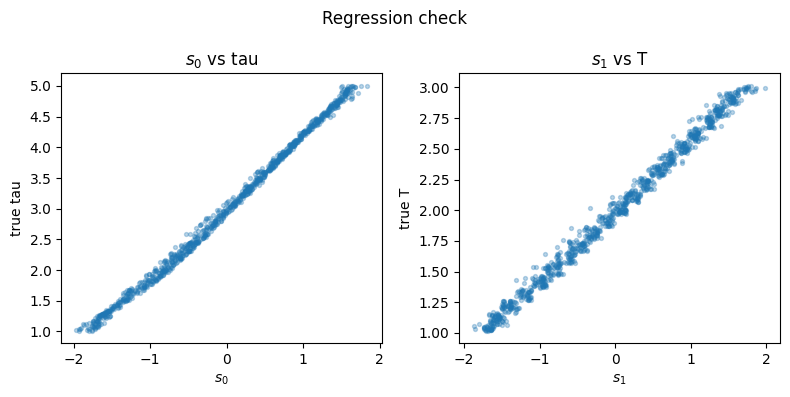

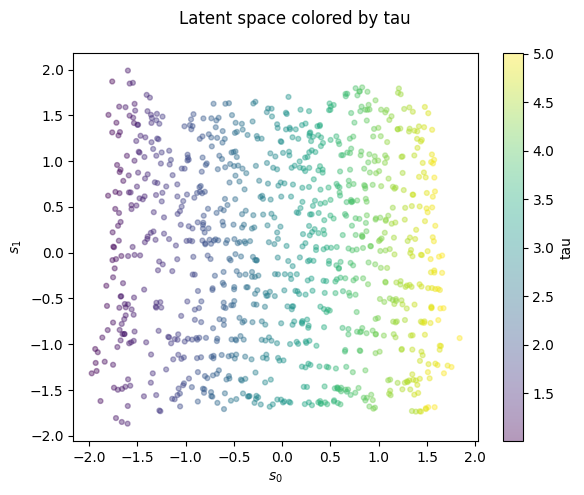

In [59]:
# load dataset
fixed = {
    "tau": None,
    "T": None,
    "Nd": 11,
    "sigma": 0.05,
    "Bmax": 5
}
data = load_train_test_datasets(fixed, 10000, 1000)

# run experiment
res2_mse = run(fixed,
    data["X_train"], data["N_train"], data["P_train"], data["stats"],
    data["X_test"], data["N_test"], data["P_test"],
    n_summary=None, epochs=200, loss="MSE")

---
# 3) Fixing 4 parameters 
## Vary $\tau$, T, $N_d$, $\sigma$
Training with paper priors

Dataset loaded.
Dataset loaded.

Training...

Epoch  20, Loss: 1.3312, LR: 8.18e-04
Epoch  40, Loss: 1.2902, LR: 6.69e-04
Epoch  60, Loss: 1.2669, LR: 5.47e-04
Epoch  80, Loss: 1.3326, LR: 4.48e-04
Epoch 100, Loss: 1.1992, LR: 3.66e-04
Epoch 120, Loss: 1.1503, LR: 2.99e-04
Epoch 140, Loss: 1.1288, LR: 2.45e-04
Epoch 160, Loss: 1.1036, LR: 2.00e-04
Epoch 180, Loss: 1.1003, LR: 1.64e-04
Epoch 200, Loss: 1.0865, LR: 1.34e-04


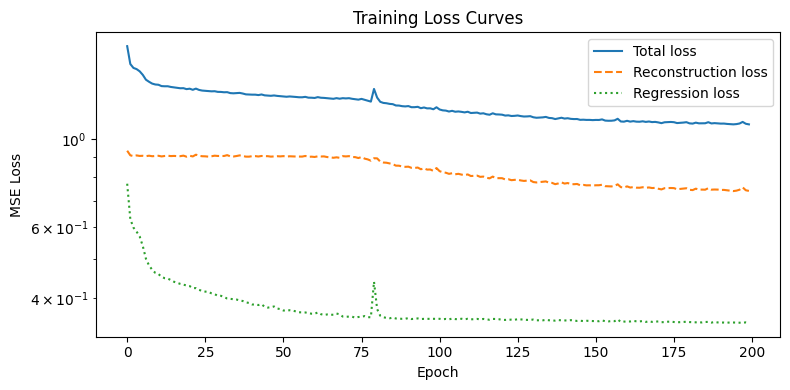


----------------------------------------------------------------------------------------------------
Evaluating on test set...


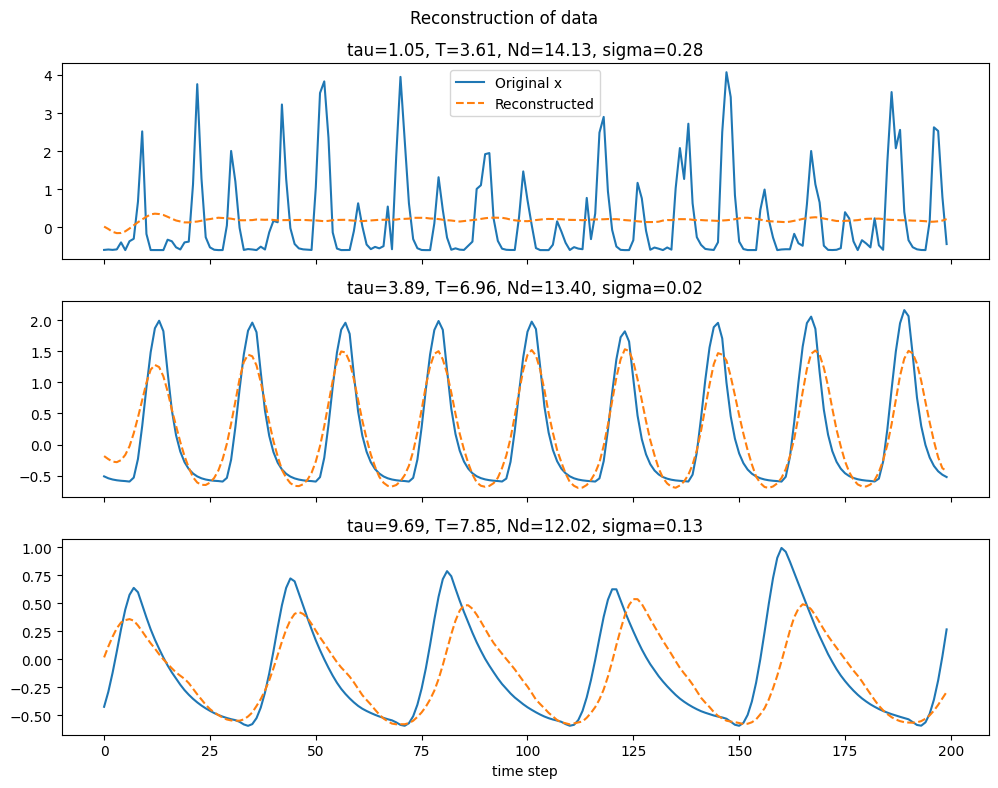

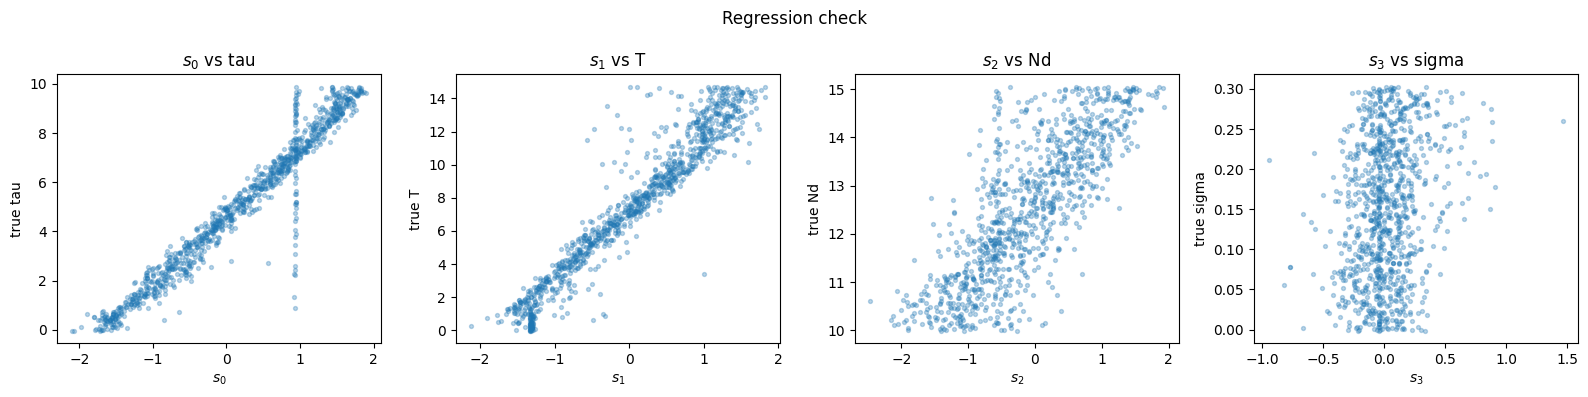

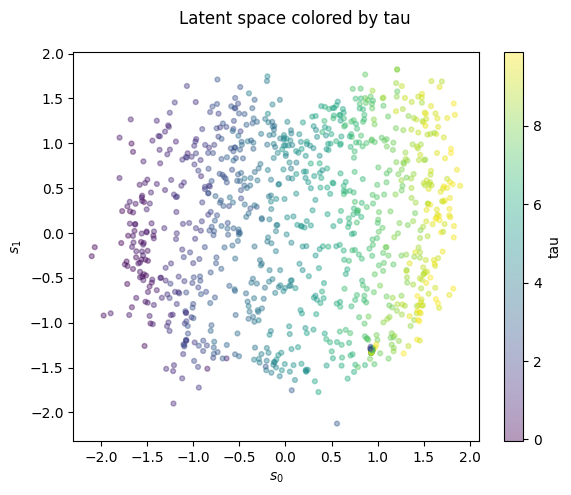

In [37]:
# load dataset
fixed = {
    "tau": None,
    "T": None,
    "Nd": None,
    "sigma": None,
    "Bmax": 5
}
data = load_train_test_datasets(fixed, 10000, 1000)

# run experiment
res1_mse = run(fixed,
    data["X_train"], data["N_train"], data["P_train"], data["stats"],
    data["X_test"], data["N_test"], data["P_test"],
    n_summary=None, epochs=200, loss="MSE")

Training with priors = {"tau": (1, 5), "T": (1, 3), "Nd": (10, 12), "sigma": (0, 0.3)}

Dataset loaded.
Dataset loaded.

Training...

Epoch  20, Loss: 1.3302, LR: 8.18e-04
Epoch  40, Loss: 1.2930, LR: 6.69e-04
Epoch  60, Loss: 1.2252, LR: 5.47e-04
Epoch  80, Loss: 1.1836, LR: 4.48e-04
Epoch 100, Loss: 1.1590, LR: 3.66e-04
Epoch 120, Loss: 1.1410, LR: 2.99e-04
Epoch 140, Loss: 1.1232, LR: 2.45e-04
Epoch 160, Loss: 1.1083, LR: 2.00e-04
Epoch 180, Loss: 1.0993, LR: 1.64e-04
Epoch 200, Loss: 1.0954, LR: 1.34e-04


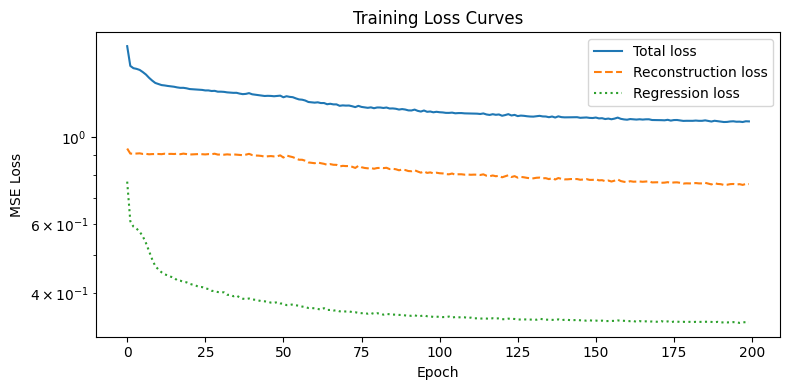


----------------------------------------------------------------------------------------------------
Evaluating on test set...


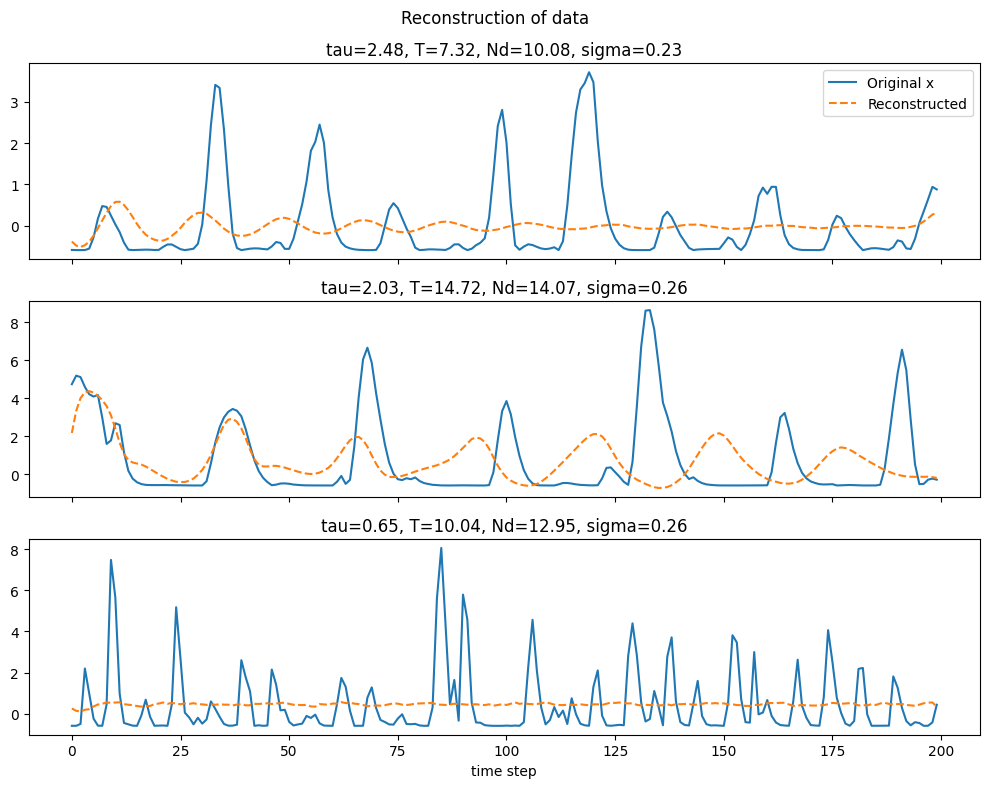

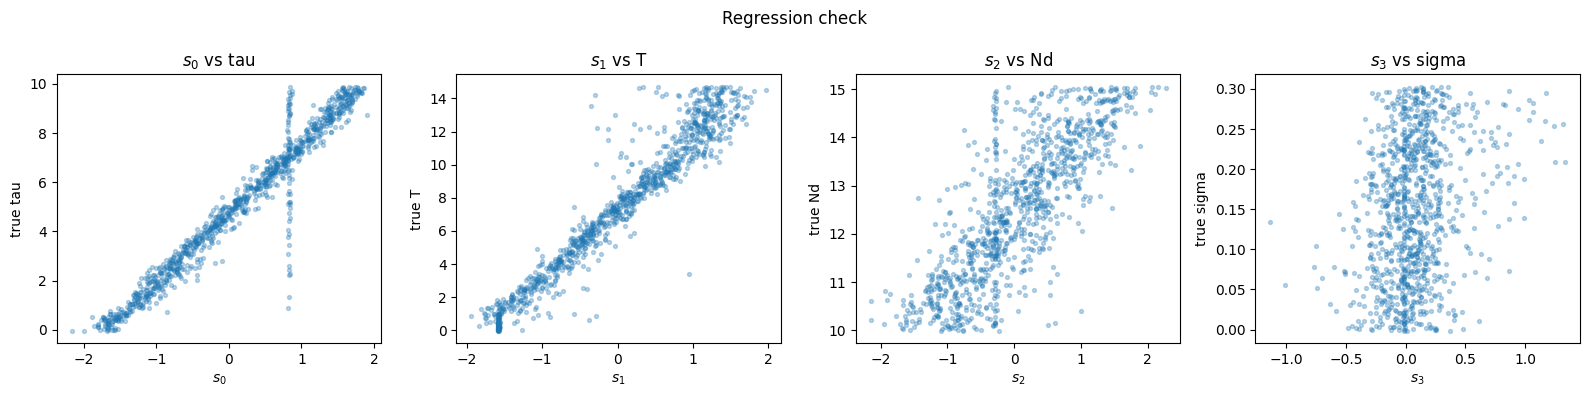

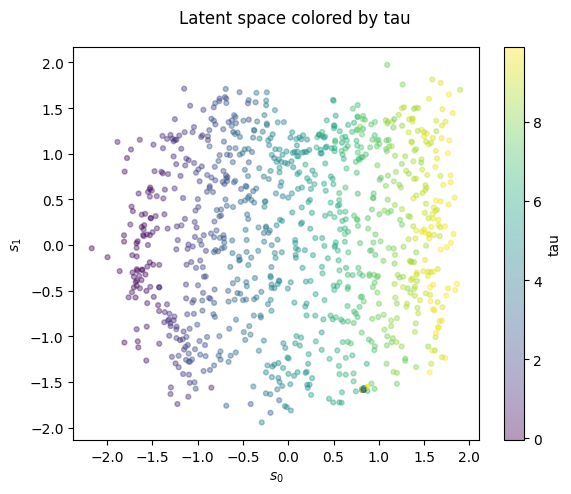

In [64]:
# load dataset
fixed = {
    "tau": None,
    "T": None,
    "Nd": None,
    "sigma": None,
    "Bmax": 5
}
data = load_train_test_datasets(fixed, 10000, 1000)

# run experiment
res1_mse = run(fixed,
    data["X_train"], data["N_train"], data["P_train"], data["stats"],
    data["X_test"], data["N_test"], data["P_test"],
    n_summary=None, epochs=200, loss="MSE")

Training with priors = {"tau": (1, 5), "T": (1, 3), "Nd": (10, 12), "sigma": (0, 0.3)}

Dataset loaded.
Dataset loaded.

Training...

Epoch  20, Loss: 1.0467, LR: 8.18e-04
Epoch  40, Loss: 1.0109, LR: 6.69e-04
Epoch  60, Loss: 0.8663, LR: 5.47e-04
Epoch  80, Loss: 0.7777, LR: 4.48e-04
Epoch 100, Loss: 0.7489, LR: 3.66e-04
Epoch 120, Loss: 0.7273, LR: 2.99e-04
Epoch 140, Loss: 0.7103, LR: 2.45e-04
Epoch 160, Loss: 0.6992, LR: 2.00e-04
Epoch 180, Loss: 0.6887, LR: 1.64e-04
Epoch 200, Loss: 0.6805, LR: 1.34e-04


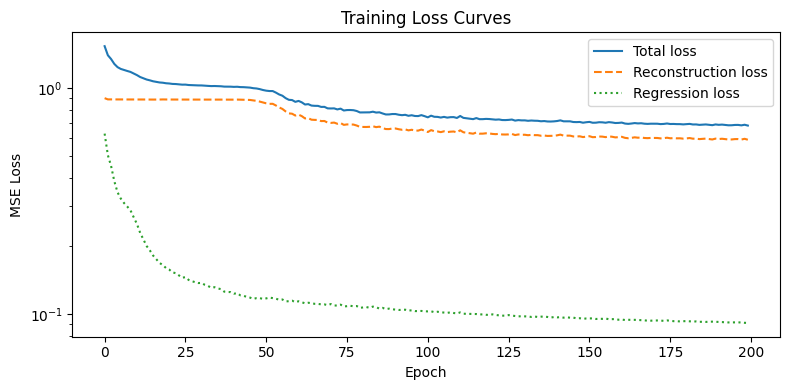


----------------------------------------------------------------------------------------------------
Evaluating on test set...


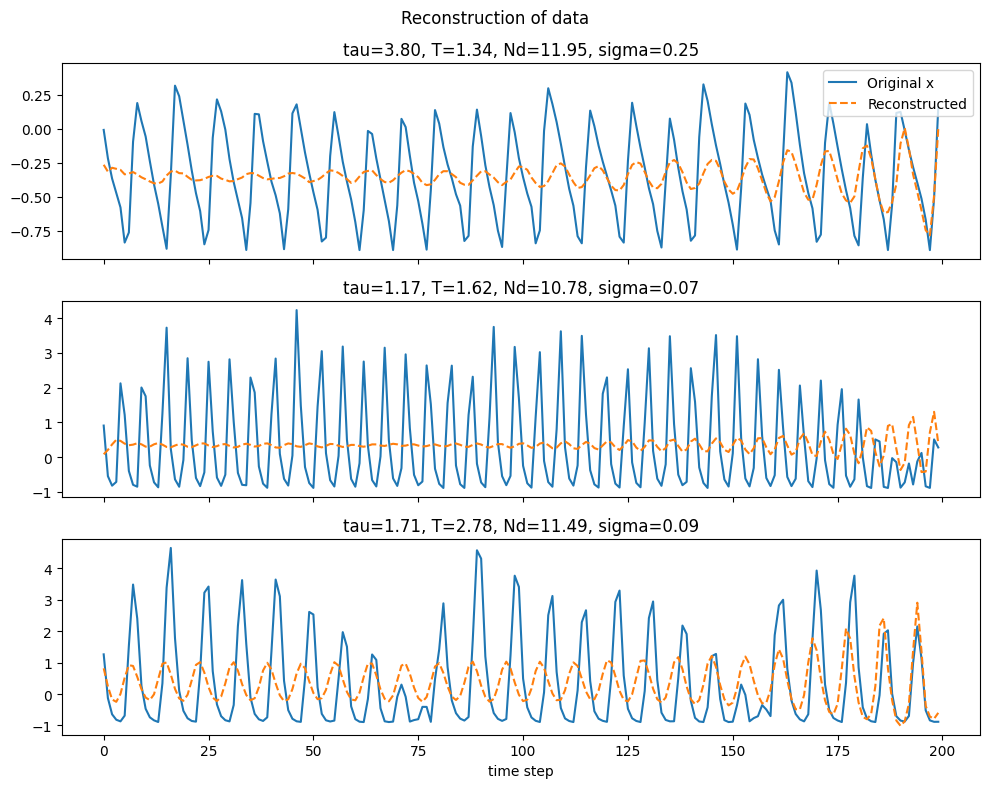

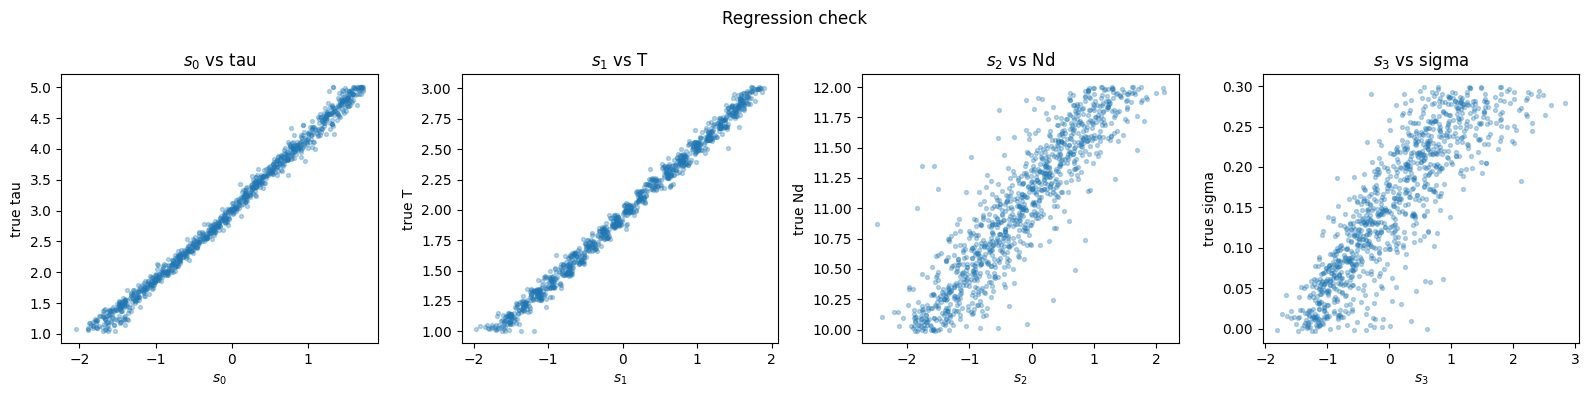

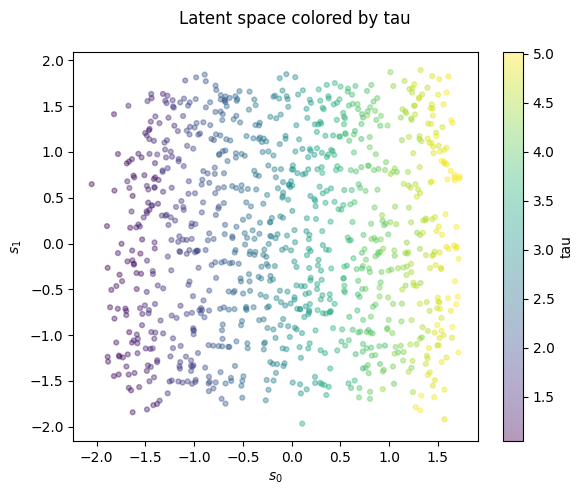

In [66]:
# load dataset
fixed = {
    "tau": None,
    "T": None,
    "Nd": None,
    "sigma": None,
    "Bmax": 5
}
data = load_train_test_datasets(fixed, 20000, 1000)

# run experiment
res1_mse = run(fixed,
    data["X_train"], data["N_train"], data["P_train"], data["stats"],
    data["X_test"], data["N_test"], data["P_test"],
    n_summary=None, epochs=200, loss="MSE")

---
# Pushing toward chaos
## $T\in [1,4]$

In [ ]:
PRIORS["T"] = (1, 4)

## $T\in[1,5]$

## $T\in[1,6]$

## $T\in[1,7]$

# Fourier Space